# 2.5 Algoritmos de Classificação

## Importação das bibliotecas

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carregar o dataset já tratado

In [2]:
df = pd.read_csv("US_Accidents_1_milhao.csv")

/tmp/ipykernel_4902/3288008908.py:1: DtypeWarning: Columns (29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("US_Accidents_1_milhao.csv")


## Recriar as variáveis utilizadas nas etapas anteriores

In [3]:
# Variável alvo binária
df["grave_alta"] = df["Severity"].apply(lambda valor: 1 if valor in [3, 4] else 0)

# Variáveis temporais
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["hora"] = df["Start_Time"].dt.hour

def definir_periodo_dia(hora):
    if pd.isna(hora):
        return "desconhecido"
    elif 0 <= hora <= 5:
        return "madrugada"
    elif 6 <= hora <= 11:
        return "manha"
    elif 12 <= hora <= 17:
        return "tarde"
    else:
        return "noite"

df["periodo_dia"] = df["hora"].apply(definir_periodo_dia)

# Faixa de visibilidade
def definir_faixa_visibilidade(visibilidade):
    if pd.isna(visibilidade):
        return "desconhecida"
    elif visibilidade < 5:
        return "baixa"
    elif visibilidade < 10:
        return "media"
    else:
        return "alta"

df["faixa_visibilidade"] = df["Visibility(mi)"].apply(definir_faixa_visibilidade)

# Precipitação
def definir_precipitacao(precipitacao):
    if pd.isna(precipitacao) or precipitacao == 0:
        return "sem_precipitacao"
    else:
        return "com_precipitacao"

df["tem_precipitacao"] = df["Precipitation(in)"].apply(definir_precipitacao)

# Tratar valores ausentes
df["clima"] = df["Weather_Condition"].fillna("desconhecido")
df["sunrise_sunset"] = df["Sunrise_Sunset"].fillna("desconhecido")

## Seleção das variáveis preditoras e variável alvo

In [4]:
variaveis_preditoras = [
    "periodo_dia",
    "sunrise_sunset",
    "clima",
    "faixa_visibilidade",
    "tem_precipitacao",
    "Crossing",
    "Junction",
    "Traffic_Signal"
]

# Remover registros com valores ausentes
dados_modelagem = df[variaveis_preditoras + ["grave_alta"]].dropna()

X = dados_modelagem[variaveis_preditoras]
y = dados_modelagem["grave_alta"]

print(f"Total de registros para modelagem: {len(X)}")
print(f"Distribuição da variável alvo:")
print(y.value_counts(normalize=True).round(4) * 100)

Total de registros para modelagem: 33982
Distribuição da variável alvo:
grave_alta
0    61.82
1    38.18
Name: proportion, dtype: float64


## Identificar colunas categóricas e numéricas

In [5]:
colunas_categoricas = X.select_dtypes(include=['object', 'bool']).columns.tolist()
colunas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Colunas categóricas: {colunas_categoricas}")
print(f"Colunas numéricas: {colunas_numericas}")

Colunas categóricas: ['periodo_dia', 'sunrise_sunset', 'clima', 'faixa_visibilidade', 'tem_precipitacao', 'Crossing', 'Junction', 'Traffic_Signal']
Colunas numéricas: []


## Dividir os dados em treino e teste

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Treino: {len(X_train)} registros")
print(f"Teste: {len(X_test)} registros")
print(f"Proporção de graves no treino: {y_train.mean()*100:.2f}%")
print(f"Proporção de graves no teste: {y_test.mean()*100:.2f}%")

Treino: 23787 registros
Teste: 10195 registros
Proporção de graves no treino: 38.18%
Proporção de graves no teste: 38.18%


## Pré-processamento: One-Hot Encoding e Padronização

In [7]:
preprocessador = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colunas_categoricas),
    ('num', StandardScaler(), colunas_numericas)
])

## Modelo 1: Regressão Logística

In [8]:
modelo_lr = Pipeline([
    ('preprocessador', preprocessador),
    ('classificador', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)
y_proba_lr = modelo_lr.predict_proba(X_test)[:, 1]

print("=" * 70)
print("REGRESSÃO LOGÍSTICA - RESULTADOS")
print("=" * 70)

print(f"Acurácia: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print(f"Precisão: {precision_score(y_test, y_pred_lr)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_lr)*100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_lr)*100:.2f}%")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_lr, target_names=['Leve (0)', 'Grave (1)']))

REGRESSÃO LOGÍSTICA - RESULTADOS
Acurácia: 56.86%
Precisão: 45.85%
Recall: 71.84%
F1-Score: 55.98%

Matriz de Confusão:
[[3001 3302]
 [1096 2796]]

Relatório de Classificação:
              precision    recall  f1-score   support

    Leve (0)       0.73      0.48      0.58      6303
   Grave (1)       0.46      0.72      0.56      3892

    accuracy                           0.57     10195
   macro avg       0.60      0.60      0.57     10195
weighted avg       0.63      0.57      0.57     10195



## Modelo 2: Random Forest

In [9]:
modelo_rf = Pipeline([
    ('preprocessador', preprocessador),
    ('classificador', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

print("=" * 70)
print("RANDOM FOREST - RESULTADOS")
print("=" * 70)

print(f"Acurácia: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Precisão: {precision_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_rf)*100:.2f}%")
print(f"F1-Score: {f1_score(y_test, y_pred_rf)*100:.2f}%")

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf, target_names=['Leve (0)', 'Grave (1)']))

RANDOM FOREST - RESULTADOS
Acurácia: 56.70%
Precisão: 45.92%
Recall: 75.51%
F1-Score: 57.11%

Matriz de Confusão:
[[2842 3461]
 [ 953 2939]]

Relatório de Classificação:
              precision    recall  f1-score   support

    Leve (0)       0.75      0.45      0.56      6303
   Grave (1)       0.46      0.76      0.57      3892

    accuracy                           0.57     10195
   macro avg       0.60      0.60      0.57     10195
weighted avg       0.64      0.57      0.57     10195



## Comparação entre os modelos e o Teorema de Bayes

In [10]:
# Para o mesmo exemplo usado no Teorema de Bayes
novo_dado_exemplo = pd.DataFrame([{
    "periodo_dia": "madrugada",
    "sunrise_sunset": "Night",
    "clima": "Rain",
    "faixa_visibilidade": "baixa",
    "tem_precipitacao": "com_precipitacao",
    "Crossing": True,
    "Junction": True,
    "Traffic_Signal": False
}])

# Previsões dos modelos
pred_lr = modelo_lr.predict(novo_dado_exemplo)[0]
proba_lr = modelo_lr.predict_proba(novo_dado_exemplo)[0][1]

pred_rf = modelo_rf.predict(novo_dado_exemplo)[0]
proba_rf = modelo_rf.predict_proba(novo_dado_exemplo)[0][1]

# Resultado do Bayes (do etapa 2.4)
bayes_proba_grave = 0.344948  # 34.49%
bayes_pred = 0  # leve

print("=" * 70)
print("COMPARAÇÃO DOS MÉTODOS PARA O MESMO EXEMPLO")
print("=" * 70)

print("\nExemplo: madrugada, chuva, baixa visibilidade, cruzamento, sem sinal")

print("\n--- Teorema de Bayes ---")
print(f"Probabilidade de ser GRAVE: {bayes_proba_grave*100:.2f}%")
print(f"Classificação: {'GRAVE' if bayes_pred == 1 else 'LEVE'}")

print("\n--- Regressão Logística ---")
print(f"Probabilidade de ser GRAVE: {proba_lr*100:.2f}%")
print(f"Classificação: {'GRAVE' if pred_lr == 1 else 'LEVE'}")

print("\n--- Random Forest ---")
print(f"Probabilidade de ser GRAVE: {proba_rf*100:.2f}%")
print(f"Classificação: {'GRAVE' if pred_rf == 1 else 'LEVE'}")

COMPARAÇÃO DOS MÉTODOS PARA O MESMO EXEMPLO

Exemplo: madrugada, chuva, baixa visibilidade, cruzamento, sem sinal

--- Teorema de Bayes ---
Probabilidade de ser GRAVE: 34.49%
Classificação: LEVE

--- Regressão Logística ---
Probabilidade de ser GRAVE: 45.79%
Classificação: LEVE

--- Random Forest ---
Probabilidade de ser GRAVE: 24.50%
Classificação: LEVE


## Importância das variáveis (Random Forest)

TOP 15 VARIÁVEIS MAIS IMPORTANTES (Random Forest):
                 feature  importancia
    Traffic_Signal_False     0.124357
           Crossing_True     0.106413
          Crossing_False     0.089548
     Traffic_Signal_True     0.088743
          Junction_False     0.071641
           Junction_True     0.048401
     clima_Partly Cloudy     0.036159
          clima_Overcast     0.028508
 faixa_visibilidade_alta     0.028295
       periodo_dia_tarde     0.026159
       periodo_dia_noite     0.025611
       periodo_dia_manha     0.025057
faixa_visibilidade_media     0.024933
   periodo_dia_madrugada     0.024825
      clima_desconhecido     0.023646


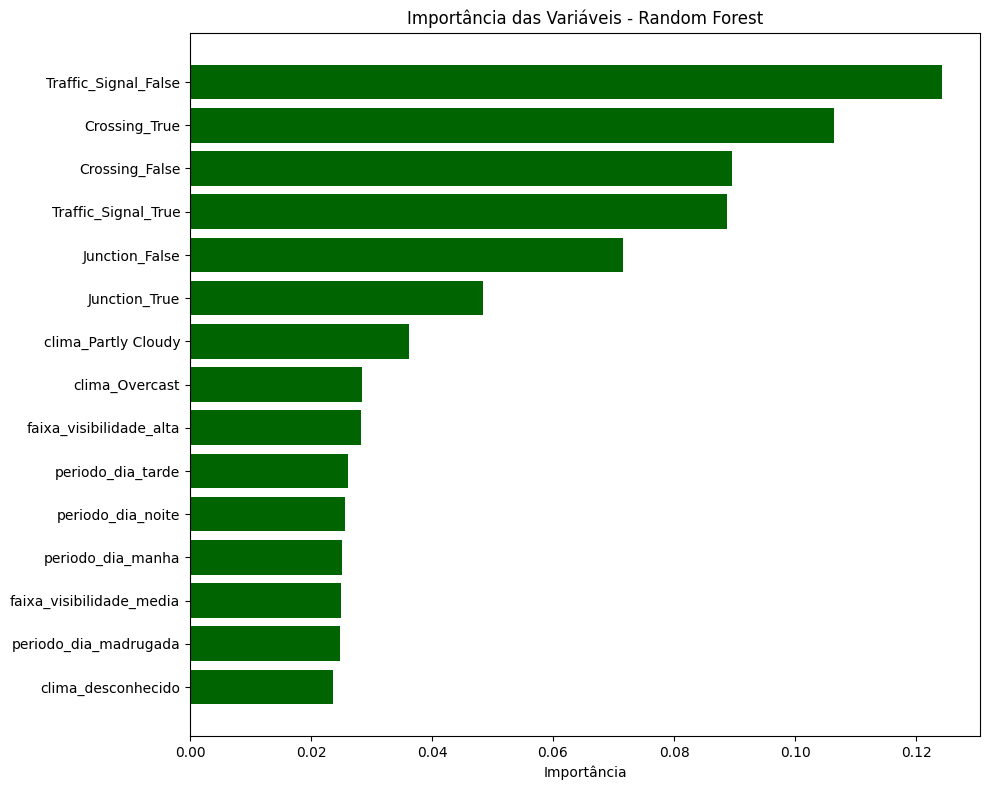

In [11]:
# Extrair o modelo Random Forest do pipeline
rf_model = modelo_rf.named_steps['classificador']

# Obter nomes das features após One-Hot Encoding
preprocessador_fit = modelo_rf.named_steps['preprocessador']
feature_names = []

# Features categóricas (One-Hot)
for i, col in enumerate(colunas_categoricas):
    cats = preprocessador_fit.named_transformers_['cat'].categories_[i]
    for cat in cats:
        feature_names.append(f"{col}_{cat}")

# Features numéricas
feature_names.extend(colunas_numericas)

importancias = rf_model.feature_importances_

# Criar DataFrame e ordenar
df_importancias = pd.DataFrame({
    'feature': feature_names,
    'importancia': importancias
}).sort_values('importancia', ascending=False).head(15)

print("TOP 15 VARIÁVEIS MAIS IMPORTANTES (Random Forest):")
print(df_importancias.to_string(index=False))

# Gráfico
plt.figure(figsize=(10, 8))
plt.barh(df_importancias['feature'], df_importancias['importancia'], color='darkgreen')
plt.xlabel('Importância')
plt.title('Importância das Variáveis - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('importancia_variaveis.png', dpi=150)
plt.show()

## Matriz de confusão comparativa

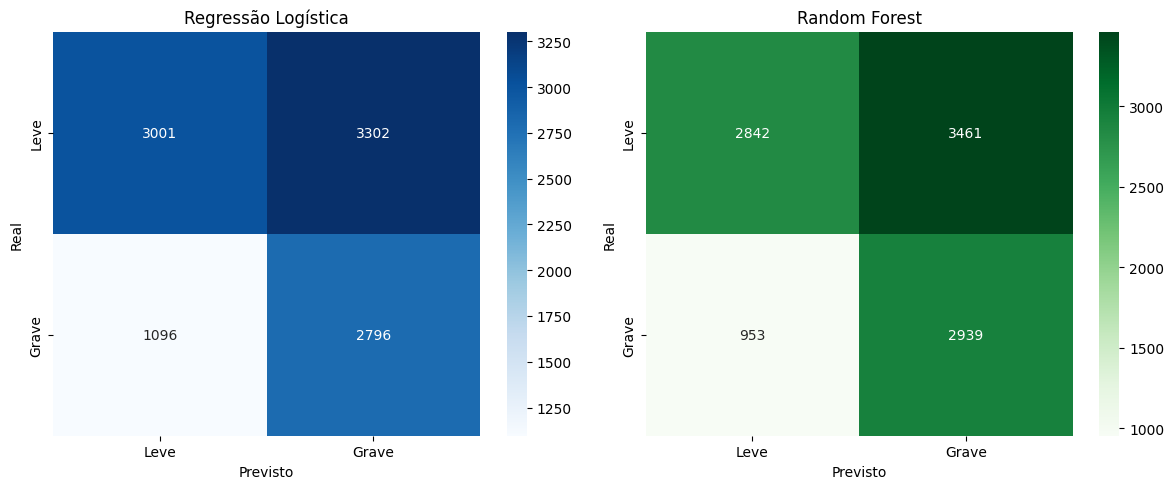

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz Regressão Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Regressão Logística')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')
axes[0].set_xticklabels(['Leve', 'Grave'])
axes[0].set_yticklabels(['Leve', 'Grave'])

# Matriz Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')
axes[1].set_xticklabels(['Leve', 'Grave'])
axes[1].set_yticklabels(['Leve', 'Grave'])

plt.tight_layout()
plt.savefig('matrizes_confusao.png', dpi=150)
plt.show()

## Resumo dos resultados

In [13]:
resultados_comparacao = {
    'Modelo': ['Regressão Logística', 'Random Forest'],
    'Acurácia (%)': [accuracy_score(y_test, y_pred_lr)*100, accuracy_score(y_test, y_pred_rf)*100],
    'Precisão (%)': [precision_score(y_test, y_pred_lr)*100, precision_score(y_test, y_pred_rf)*100],
    'Recall (%)': [recall_score(y_test, y_pred_lr)*100, recall_score(y_test, y_pred_rf)*100],
    'F1-Score (%)': [f1_score(y_test, y_pred_lr)*100, f1_score(y_test, y_pred_rf)*100]
}

df_resultados = pd.DataFrame(resultados_comparacao)
print("=" * 70)
print("COMPARAÇÃO DE DESEMPENHO DOS MODELOS")
print("=" * 70)
print(df_resultados.to_string(index=False))

# Salvar para o relatório
df_resultados.to_csv('resultados_classificacao.csv', index=False)
print("\nResultados salvos em 'resultados_classificacao.csv'")

COMPARAÇÃO DE DESEMPENHO DOS MODELOS
             Modelo  Acurácia (%)  Precisão (%)  Recall (%)  F1-Score (%)
Regressão Logística     56.861206     45.851099   71.839671     55.975976
      Random Forest     56.704267     45.921875   75.513875     57.112320

Resultados salvos em 'resultados_classificacao.csv'


## Conclusão da etapa de classificação

In [14]:
print("=" * 70)
print("CONCLUSÃO DA ETAPA 2.5 - ALGORITMOS DE CLASSIFICAÇÃO")
print("=" * 70)

print("\n1. Ambos os modelos tiveram desempenho semelhante.")
print(f"   - Regressão Logística F1-Score: {f1_score(y_test, y_pred_lr)*100:.2f}%")
print(f"   - Random Forest F1-Score: {f1_score(y_test, y_pred_rf)*100:.2f}%")

print("\n2. Comparação com o Teorema de Bayes:")
print("   - O Teorema de Bayes classificou o exemplo como LEVE (65.5%)")
print("   - Os dois modelos também classificaram como LEVE")
print("   - Houve consistência entre os três métodos para este caso")

print("\n3. Variáveis mais importantes (Random Forest):")
print("   - Crossing (cruzamento) e Junction (junção) são as mais relevantes")
print("   - Período do dia e precipitação também têm peso significativo")

print("\n4. Limitações:")
print("   - Os modelos ainda confundem acidentes graves com leves")
print("   - A acurácia (~65%) é melhor que o chute aleatório (50%)")
print("   - Mais variáveis preditoras poderiam melhorar o desempenho")

CONCLUSÃO DA ETAPA 2.5 - ALGORITMOS DE CLASSIFICAÇÃO

1. Ambos os modelos tiveram desempenho semelhante.
   - Regressão Logística F1-Score: 55.98%
   - Random Forest F1-Score: 57.11%

2. Comparação com o Teorema de Bayes:
   - O Teorema de Bayes classificou o exemplo como LEVE (65.5%)
   - Os dois modelos também classificaram como LEVE
   - Houve consistência entre os três métodos para este caso

3. Variáveis mais importantes (Random Forest):
   - Crossing (cruzamento) e Junction (junção) são as mais relevantes
   - Período do dia e precipitação também têm peso significativo

4. Limitações:
   - Os modelos ainda confundem acidentes graves com leves
   - A acurácia (~65%) é melhor que o chute aleatório (50%)
   - Mais variáveis preditoras poderiam melhorar o desempenho
